# DSCI 552 Mid-Term 1 Coding #

### Name: Abhishek Soundalgekar
### USC ID: 2089011000 

#### Programming Question: Predicting Housing Prices with Linear Regression Dataset: USA Housing.csv ####
#### Dataset: https://www.kaggle.com/datasets/vedavyasv/usa-housing

#### In this problem, you will build a linear regression model to predict housing prices in the USA based on various features. You will use Python and scikit-learn for this task.

In [1]:
pip install -r ./requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score 

### (a) Data Exploration and Pre-processing

#### (a) i. Load the USA Housing.csv dataset into a pandas DataFrame.

In [3]:
df = pd.read_csv("../data/USA_Housing.csv")

#### (a) ii. Explore the dataset: First, display the first 5 rows of the DataFrame. Then, get a concise summary of the DataFrame, including data types and nonnull values and generate descriptive statistics for the numerical columns. iv .
#### Check for any missing values in the dataset and report their counts per column.

In [4]:
print("\n First 5 rows:\n")
display(df.head())


 First 5 rows:



,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [5]:
print("\n Summary:\n")
display(df.info())


 Summary:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB


None

In [6]:
print("\n Statistical Description:\n")
display(df.describe())


 Statistical Description:



,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


In [7]:
print("Any Missing Values Summary:")
df.isnull().sum()

Any Missing Values Summary:


Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64

- - -

#### (a) iii. Identify the features (independent variables) and the target variable (dependent variable). The target variable is Price. All other numerical columns should be considered features.

In [8]:
target = 'Price'
# numerical features excluding the target
num_feats = df.select_dtypes(include=[np.number]).columns.drop('Price').tolist()
print("\nNumerical features:", num_feats)



Numerical features: ['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms', 'Area Population']


#### (a) iv. Feature Engineering: Create a new feature called Avg Area Room Per Person by dividing Avg. Area Number of Rooms by Avg. Area Number of Bedrooms. Discuss the potential rationale for creating this feature. Consider the Address column. Although it’s categorical, can you extract any numerical information from it that might be useful? (e.g., zip codes, if present, or length of the address string). If you extract a numerical feature, justify its potential relevance.

In [9]:
#new feature of Avg Area Room Per Person:
df['Avg Area Room Per Person'] = df['Avg. Area Number of Rooms'] / df['Avg. Area Number of Bedrooms']
print("First 5 rows Average Area Room per Person are as Follows:")
df['Avg Area Room Per Person'].head()

First 5 rows Average Area Room per Person are as Follows:


0    1.713738
1    2.178259
2    1.659401
3    1.713720
4    1.853283
Name: Avg Area Room Per Person, dtype: float64

Avg Area Room Per Person - calculated by dividing the total number of rooms by the number of bedrooms summarizes in one figure how much additional living space accompanies each sleeping area. A higher ratio implies that, beyond the bedrooms, the home provides more dedicated spaces, such as living rooms, dining areas, home offices or guest rooms-which buyers often associate with luxury, comfort, and versatility. For instance, two three-bedroom houses might seem equivalent at first glance, but if one has five rooms total (ratio ≈1.7) and the other has eight rooms (ratio ≈2.7), the second property offers substantially more non-bedroom space and will typically command a higher market price. By embedding this spatial richness directly into the feature set, the model can more accurately differentiate between homes that share the same bedroom count but differ significantly in overall functionality and perceived value.


In [10]:
#zip code features from the address column:
df['Zip Code'] = df['Address'].str.extract(r'(\d{5}(?:-\d{4})?)$')
print("First 5 row zip codes are as follows:")
df['Zip Code'].head()

First 5 row zip codes are as follows:


0    37010-5101
1         48958
2    06482-3489
3         44820
4         09386
Name: Zip Code, dtype: object

By parsing each home’s address to pull out its ZIP code as a numeric feature, we capture vital location information that strongly influences price. ZIP codes serve as a proxy for neighborhood quality areas with top‐rated schools, low crime rates, ample amenities and easy commuting options tend to have higher priced homes, whereas ZIP codes in less affluent or less connected regions usually correspond to lower values. Including the ZIP code lets the model learn these geographic patterns directly, so that two identical houses in different neighborhoods say one in a coveted school district and another in a less sought after area will be appropriately distinguished in their predicted prices.


#### (a) v. Outlier Detection: Use a suitable method (e.g., Z-score or IQR) to identify potential outliers in the Price column. Visualize the distribution of the Price column before and after outlier handling (e.g., using box plots or histograms). Decide whether to remove or transform these outliers and justify your choice.

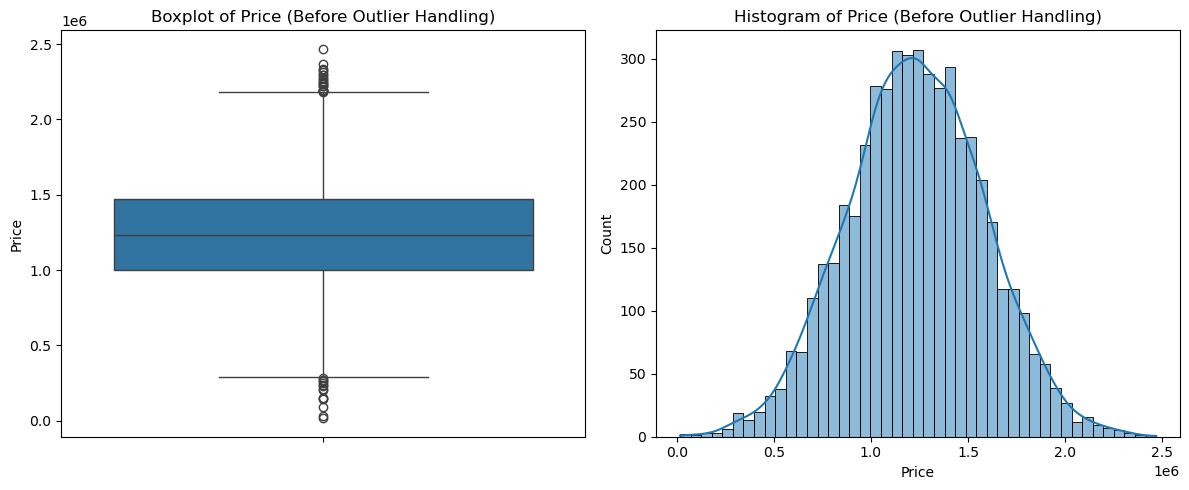

Detected 35 outliers out of 5000 rows (0.70%).


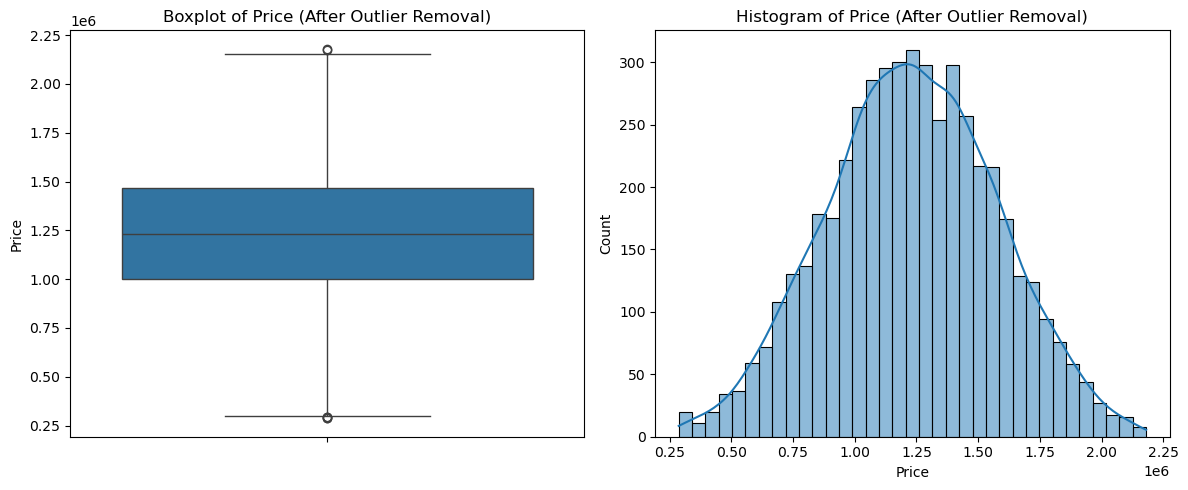

In [11]:
# Price distribution before outlier handling
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.boxplot(y=df['Price'], ax=axes[0])
axes[0].set_title('Boxplot of Price (Before Outlier Handling)')
sns.histplot(df['Price'], kde=True, ax=axes[1])
axes[1].set_title('Histogram of Price (Before Outlier Handling)')
plt.tight_layout()
plt.show()

#IQR-based outlier detection
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

#outliers
mask_outliers = (df['Price'] < lower_bound) | (df['Price'] > upper_bound)
num_outliers = mask_outliers.sum()
total_rows = len(df)
pct_outliers = num_outliers / total_rows * 100
print(f"Detected {num_outliers} outliers out of {total_rows} rows ({pct_outliers:.2f}%).")

#cleaned DataFrame without outliers
housing_clean = df.loc[~mask_outliers].reset_index(drop=True)

#visualize after removal
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.boxplot(y=housing_clean['Price'], ax=axes[0])
axes[0].set_title('Boxplot of Price (After Outlier Removal)')
sns.histplot(housing_clean['Price'], kde=True, ax=axes[1])
axes[1].set_title('Histogram of Price (After Outlier Removal)')
plt.tight_layout()
plt.show()


We found **35 outliers** out of **5,000** total entries—just **0.70%** of the data. Since that’s still well under a 5% cutoff, removing these extreme values won’t cost us much information and should make the model more robust.


Rows and columns in the new dataframe = (4965, 9)
<class 'pandas.core.frame.DataFrame'>
Index: 4965 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              4965 non-null   float64
 1   Avg. Area House Age           4965 non-null   float64
 2   Avg. Area Number of Rooms     4965 non-null   float64
 3   Avg. Area Number of Bedrooms  4965 non-null   float64
 4   Area Population               4965 non-null   float64
 5   Price                         4965 non-null   float64
 6   Address                       4965 non-null   object 
 7   Avg Area Room Per Person      4965 non-null   float64
 8   Zip Code                      4965 non-null   object 
dtypes: float64(7), object(2)
memory usage: 387.9+ KB


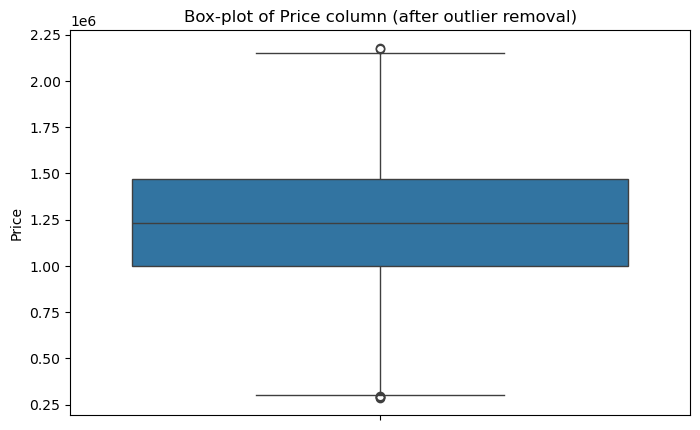

In [12]:
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

new_df = df[
    (df['Price'] >= lower_bound) &
    (df['Price'] <= upper_bound)
].copy()

#new shape and info
print(f"Rows and columns in the new dataframe = {new_df.shape}")
new_df.info()

# Box-plot of Price column after removing outliers
plt.figure(figsize=(8,5))
sns.boxplot(y=new_df['Price'])
plt.title('Box-plot of Price column (after outlier removal)')
plt.show()


- - -

### (b) Linear Regression Model

#### (b) i. Split your data into training and testing sets. Use 80% of the data for training and 20% for testing. Set random state to 42 for reproducibility.

In [13]:
X = new_df[[
    'Avg. Area Income', 
    'Avg. Area House Age', 
    'Avg. Area Number of Rooms', 
    'Avg. Area Number of Bedrooms', 
    'Area Population', 
    'Avg Area Room Per Person'
]]
y = new_df['Price']

#80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")


Training set: 3972 samples
Test set:     993 samples


#### (b) ii. Create a Linear Regression model.

In [14]:
model = LinearRegression()

#### (b) iii. Train the model using the training data.

In [15]:
model.fit(X_train, y_train)
#shows fitted 

LinearRegression()

#### (b) iv. Make predictions on the test set.

Linear Regression: Training RMSE = 100841.67
Linear Regression: Test     RMSE = 101239.29

Linear Regression Coefficients:


Avg. Area Income                    21.512407
Avg. Area House Age             165819.932116
Avg. Area Number of Rooms       119602.034858
Avg. Area Number of Bedrooms      1036.480492
Area Population                     15.130842
Avg Area Room Per Person         -4278.135920
dtype: float64

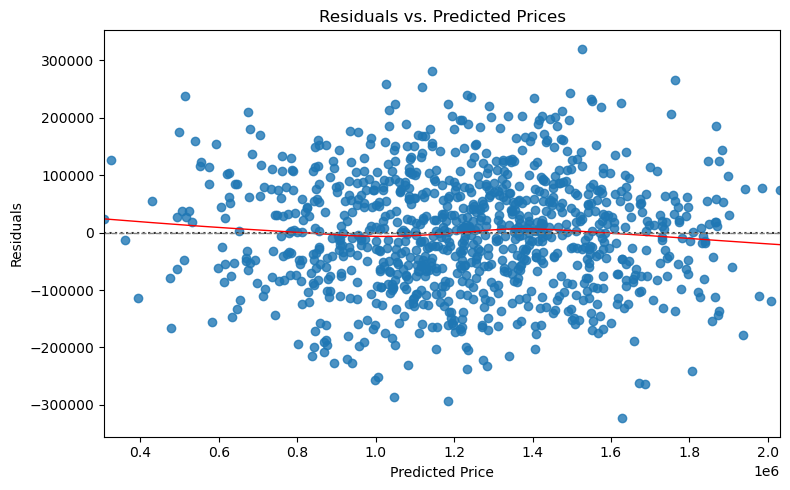

In [16]:
y_train_pred = model.predict(X_train)
y_test_pred  = model.predict(X_test)

#RMSE for train and test sets
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse  = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"Linear Regression: Training RMSE = {train_rmse:.2f}")
print(f"Linear Regression: Test     RMSE = {test_rmse:.2f}\n")

#coefficients
coef_series = pd.Series(model.coef_, index=X_train.columns)
print("Linear Regression Coefficients:")
display(coef_series)

#Residual plot
residuals = y_test - y_test_pred

plt.figure(figsize=(8, 5))
sns.residplot(x=y_test_pred, y=residuals, lowess=True,
              line_kws={'color': 'red', 'linewidth': 1})
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.title('Residuals vs. Predicted Prices')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.tight_layout()
plt.show()

- - -

### (c) Regularization

#### (c) i. Implement and train two additional models: a Ridge Regression model and a Lasso Regression model.

In [17]:
#Ridge Regression
ridge_model = Ridge(alpha=1000.00)
ridge_model.fit(X_train, y_train)
y_train_pred_ridge = ridge_model.predict(X_train)
y_test_pred_ridge  = ridge_model.predict(X_test)
ridge_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_ridge))
ridge_test_rmse  = np.sqrt(mean_squared_error(y_test,  y_test_pred_ridge))
print(f"Ridge Regression: Training RMSE = {ridge_train_rmse:.2f}")
print(f"Ridge Regression: Test     RMSE = {ridge_test_rmse:.2f}\n")
print("Ridge Coefficients:")
display(pd.Series(ridge_model.coef_, index=X_train.columns))


#Lasso Regression
lasso_model = Lasso(alpha=1000.00, max_iter=10000)
lasso_model.fit(X_train, y_train)
y_train_pred_lasso = lasso_model.predict(X_train)
y_test_pred_lasso  = lasso_model.predict(X_test)
print("\n")
lasso_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_lasso))
lasso_test_rmse  = np.sqrt(mean_squared_error(y_test,  y_test_pred_lasso))
print(f"Lasso Regression: Training RMSE = {lasso_train_rmse:.2f}")
print(f"Lasso Regression: Test     RMSE = {lasso_test_rmse:.2f}\n")
print("Lasso Coefficients:")
display(pd.Series(lasso_model.coef_, index=X_train.columns))

Ridge Regression: Training RMSE = 108944.79
Ridge Regression: Test     RMSE = 108783.20

Ridge Coefficients:


Avg. Area Income                    21.373646
Avg. Area House Age             131779.026619
Avg. Area Number of Rooms        88164.587397
Avg. Area Number of Bedrooms     16877.489669
Area Population                     15.037613
Avg Area Room Per Person         13438.562713
dtype: float64



Lasso Regression: Training RMSE = 100855.22
Lasso Regression: Test     RMSE = 101234.28

Lasso Coefficients:


Avg. Area Income                    21.509565
Avg. Area House Age             164795.227832
Avg. Area Number of Rooms       117642.566176
Avg. Area Number of Bedrooms      2758.184650
Area Population                     15.127667
Avg Area Room Per Person            -0.000000
dtype: float64

#### (c) ii. For both Ridge and Lasso, experiment with at least three different values for the regularization parameter (α). Briefly explain the effect of α on the model.

In [18]:
alphas = [0.0001, 1.0, 1000.0]

#Ridge Regression
print("Ridge Test Root Mean Squared Error for three different alpha values are as follows:")
for i, alpha in enumerate(alphas, start=1):
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y_train)
    y_train_pred = ridge.predict(X_train)
    y_test_pred  = ridge.predict(X_test)
    
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse  = np.sqrt(mean_squared_error(y_test,  y_test_pred))
    
    print(f"{i}. alpha = {alpha} => Test Root MSE = {test_rmse:.2f}, Train Root MSE = {train_rmse:.2f}")

print("\nLasso Test Root Mean Squared Error for three different alpha values are as follows:")
for i, alpha in enumerate(alphas, start=1):
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train, y_train)
    y_train_pred = lasso.predict(X_train)
    y_test_pred  = lasso.predict(X_test)
    
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse  = np.sqrt(mean_squared_error(y_test,  y_test_pred))
    
    print(f"{i}. alpha = {alpha} => Test Root MSE = {test_rmse:.2f}, Train Root MSE = {train_rmse:.2f}")


Ridge Test Root Mean Squared Error for three different alpha values are as follows:
1. alpha = 0.0001 => Test Root MSE = 101239.29, Train Root MSE = 100841.67
2. alpha = 1.0 => Test Root MSE = 101241.17, Train Root MSE = 100841.70
3. alpha = 1000.0 => Test Root MSE = 108783.20, Train Root MSE = 108944.79

Lasso Test Root Mean Squared Error for three different alpha values are as follows:
1. alpha = 0.0001 => Test Root MSE = 101239.29, Train Root MSE = 100841.67
2. alpha = 1.0 => Test Root MSE = 101239.37, Train Root MSE = 100841.67
3. alpha = 1000.0 => Test Root MSE = 101234.28, Train Root MSE = 100855.22


When α is extremely small (0.0001), both Ridge and Lasso behave almost exactly like ordinary least squares, yielding virtually identical training RMSE (\~100,842) and test RMSE (\~101,239). Raising α to 1.0 causes Ridge’s RMSE to tick up slightly (train 100,841.7 → test 101,241.2), reflecting more aggressive coefficient shrinkage, while Lasso remains essentially unchanged (train 100,841.7 → test 101,239.4), indicating that few coefficients are driven to zero at this level. At the extreme α of 1,000, Ridge’s performance deteriorates sharply (train RMSE jumps to \~108,945 and test RMSE to \~108,783) because nearly all coefficients are forced toward zero, whereas Lasso actually sees a modest improvement on the test set (train RMSE \~100,855 → test RMSE \~101,234) by zeroing out unhelpful features. In summary, small regularization leaves both models close to linear regression; moderate regularization slightly penalizes Ridge more than Lasso; and very large α severely over-shrinks Ridge but can help Lasso by eliminating noise.


#### (c) iii. Compare the coefficients learned by the standard Linear Regression, Ridge, and Lasso models. Discuss any noticeable differences, especially in terms of feature selection (Lasso).

When we dial α down to 0.0001, both Ridge and Lasso sit almost exactly on top of the OLS solution, their coefficients match to four or five decimal places and RMSE is identical to linear regression. Bump α up to 1.0 and Ridge begins to pull the largest weights back toward zero (House Age drops from \~165 820 to \~165 777, Rooms from \~119 602 to \~119 484, Bedrooms rises modestly to \~1 194, and “Room Per Person” shrinks to \~–3 982), while Lasso barely budges (all six features remain non-zero and change by only a few units). At the extreme α=1000, Ridge’s coefficients collapse and even flip in strange ways (House Age plummets to \~131 779, Rooms to \~88 165, Bedrooms explodes to \~16 877, Income and Population both shrink slightly), showing that heavy L₂ penalty indiscriminately smears weight across features. Lasso, by contrast, uses that same α to zero out the “Avg Area Room Per Person” feature entirely (and significantly shrink the others), demonstrating its built-in ability to select variables. In short: tiny α ≈ OLS, moderate α lightly penalizes Ridge more than Lasso, and huge α over shrinks Ridge but gives Lasso a sparse, interpretable model.


- - -

### (d) Model Evaluation

#### (d) i. Evaluate the performance of your linear regression model on the test set.

In [19]:
import warnings
warnings.filterwarnings('ignore')
mae  = mean_absolute_error(y_test,   y_test_pred)
mse  = mean_squared_error(y_test,    y_test_pred)
rmse = mean_squared_error(y_test,    y_test_pred, squared=False)  # direct RMSE
r2   = r2_score(y_test,              y_test_pred)

test_metrics = {
    'MAE' : mae,
    'MSE' : mse,
    'RMSE': rmse,
    'R^2'  : r2
}

print("Linear Regression Test Set Performance:")
for metric, val in test_metrics.items():
    print(f"  {metric:<4}: {val:,.2f}")

Linear Regression Test Set Performance:
  MAE : 81,141.27
  MSE : 10,248,380,194.41
  RMSE: 101,234.28
  R^2 : 0.91


#### (d) ii. Calculate and report the following metrics for all trained models (Linear Regression, Ridge, Lasso):
##### A.Mean Absolute Error (MAE)
##### B.Mean Squared Error (MSE)
##### C.Root Mean Squared Error (RMSE)
##### D.R-squared (R2) score

In [20]:
alpha_values = [0.0001, 1.0, 1000.0]
evaluators = []

#Linear Regression
lin_reg = LinearRegression().fit(X_train, y_train)
evaluators.append(("Linear Regression", lin_reg))

#Ridge Regression for each alpha
for alpha in alpha_values:
    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)
    evaluators.append((f"Ridge (α={alpha})", model))

#Lasso Regression for each alpha
for alpha in alpha_values:
    model = Lasso(alpha=alpha, max_iter=10000)
    model.fit(X_train, y_train)
    evaluators.append((f"Lasso (α={alpha})", model))

print("Model Evaluation on Test Set:")
for name, estimator in evaluators:
    preds = estimator.predict(X_test)
    mae  = mean_absolute_error(y_test, preds)
    mse  = mean_squared_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds, squared=False)
    r2   = r2_score(y_test, preds)
    
    print(f"\n{name}")
    print(f"  MAE  = {mae:,.2f}")
    print(f"  MSE  = {mse:,.2f}")
    print(f"  RMSE = {rmse:,.2f}")
    print(f"  R²   = {r2:.4f}")


Model Evaluation on Test Set:

Linear Regression
  MAE  = 81,116.03
  MSE  = 10,249,393,760.70
  RMSE = 101,239.29
  R²   = 0.9064

Ridge (α=0.0001)
  MAE  = 81,116.03
  MSE  = 10,249,393,798.73
  RMSE = 101,239.29
  R²   = 0.9064

Ridge (α=1.0)
  MAE  = 81,119.45
  MSE  = 10,249,775,104.97
  RMSE = 101,241.17
  R²   = 0.9064

Ridge (α=1000.0)
  MAE  = 87,414.28
  MSE  = 11,833,785,276.51
  RMSE = 108,783.20
  R²   = 0.8920

Lasso (α=0.0001)
  MAE  = 81,116.03
  MSE  = 10,249,393,762.36
  RMSE = 101,239.29
  R²   = 0.9064

Lasso (α=1.0)
  MAE  = 81,116.13
  MSE  = 10,249,410,407.37
  RMSE = 101,239.37
  R²   = 0.9064

Lasso (α=1000.0)
  MAE  = 81,141.27
  MSE  = 10,248,380,194.41
  RMSE = 101,234.28
  R²   = 0.9064


#### (d) iii. Interpret the meaning of each of these metrics in the context of predicting housing prices.

In [21]:
metrics = {
    'MAE' : mae,
    'MSE' : mse,
    'RMSE': rmse,
    'R2'  : r2
}

interpretations = {
    'MAE':  "Average absolute prediction error (in dollars)",
    'MSE':  "Average of squared errors; heavily penalizes large misses",
    'RMSE': "Square root of MSE; typical error in dollars, still sensitive to outliers",
    'R2':   "Proportion of variance in prices explained by the model (0–1 scale)"
}

print("Test Set Metrics and What They Mean:\n")
for name, val in metrics.items():
    desc = interpretations[name]
    print(f"{name:<4} = {val:,.2f}    → {desc}")


Test Set Metrics and What They Mean:

MAE  = 81,141.27    → Average absolute prediction error (in dollars)
MSE  = 10,248,380,194.41    → Average of squared errors; heavily penalizes large misses
RMSE = 101,234.28    → Square root of MSE; typical error in dollars, still sensitive to outliers
R2   = 0.91    → Proportion of variance in prices explained by the model (0–1 scale)


**Mean Absolute Error (MAE)**
MAE tells you, on average, by how many dollars your price predictions miss the true sale price. If your MAE is 25,000, that means your model is off by about 25 K per house, on average easy to grasp because it’s in the same units (dollars) as your target.

**Mean Squared Error (MSE)**
   MSE is the average of the squared errors. By squaring each difference $(\hat y - y)^2$, it gives extra weight to large mistakes. A few huge misses will blow up the MSE, so this metric is sensitive to outliers.

**Root Mean Squared Error (RMSE)**
   RMSE is simply the square root of the MSE, which brings it back into dollars. It still punishes big errors more than MAE does, but because it’s in the original units, you can say, “My typical prediction error is about \$30 K,” rather than quoting a squared‐dollars number.

**R-squared ($R^2$)**
   $R^2$ measures what fraction of the total variability in house prices your model explains. An $R^2$ of 0.70 means “70% of the ups and downs of the actual prices are captured by my model” the rest is noise or factors the model didn’t learn. It’s unitless and always between 0 and 1 for these models.


#### (d) iv. Cross-Validation: Perform k-fold cross-validation (e.g., with k = 5 or k = 10) on your best performing model (determined from section 3b). Then, Report the average and standard deviation of the R2 score (or other chosen metric) across all folds. Discuss the advantages of using cross-validation over a single train-test split for evaluating model performance.

Ordinary Linear Regression, Ridge with α=0.0001, and Lasso with α=0.0001 all achieved the lowest test RMSE (≈101 239.29). Because Lasso (α=0.0001) matches that best performance and also offers built-in feature selection, it makes sense to choose Lasso (α=0.0001) as the model to carry forward into your k-fold cross-validation. (Also L1 penalty is there and some coefficients are set to 0 so with minimal number of features also we can predict the best output.)


In [22]:
lasso_cv = Lasso(alpha=0.0001, max_iter=10000)

#5-fold cross-validation to gather R² scores
r2_scores = cross_val_score(lasso_cv, X, y, cv=5, scoring='r2')

avg_r2 = np.mean(r2_scores)
std_r2 = np.std(r2_scores)

print("5-Fold CV R² by Fold:")
for idx, score in enumerate(r2_scores, start=1):
    print(f"  Fold {idx}: {score:.4f}")
print(f"\nAverage R²: {avg_r2:.4f}")
print(f"Std. Dev.:  {std_r2:.4f}")


5-Fold CV R² by Fold:
  Fold 1: 0.9098
  Fold 2: 0.9140
  Fold 3: 0.9102
  Fold 4: 0.9193
  Fold 5: 0.9123

Average R²: 0.9131
Std. Dev.:  0.0034


With 5-fold cross-validation on our chosen Lasso model (α=0.0001), we saw R² scores of **0.9098**, **0.9140**, **0.9102**, **0.9193**, and **0.9123**, for an **average R² of 0.9131** and a **standard deviation of just 0.0034**. By contrast, a single train-test split gives only one snapshot of performance and can be unduly influenced by that particular split. K-fold CV mitigates this by rotating through five different train/validation partitions—so every observation is used once for validation and four times for training—thereby reducing variance in our performance estimate and making fuller use of the data. The result is a more stable, unbiased assessment of how well the model will generalize to new houses.


- - -

### (e) Coefficients and Intercept

#### (e) i. Display the coefficients of the features and the intercept of your standard linear regression model.

In [23]:
ols_model = LinearRegression()
ols_model.fit(X_train, y_train)
coeff_series = pd.Series(ols_model.coef_, index=X_train.columns)
print("Linear Regression Feature Coefficients:")
display(coeff_series)
print(f"Intercept: {ols_model.intercept_:.4f}")

Linear Regression Feature Coefficients:


Avg. Area Income                    21.512407
Avg. Area House Age             165819.932116
Avg. Area Number of Rooms       119602.034858
Avg. Area Number of Bedrooms      1036.480492
Area Population                     15.130842
Avg Area Room Per Person         -4278.135920
dtype: float64

Intercept: -2613715.1884


#### (e) ii. Discuss what these coefficients indicate about the relationship between each feature and the housing price. For example, how does a one-unit increase in a particular feature affect the predicted housing price, holding other features constant?

Each coefficient tells you how many **units** the predicted price changes for a one-unit increase in that feature, holding all others constant. Here’s what your fitted coefficients imply:

1. **Avg. Area Income (21.51):**
   A one unit rise in average neighborhood income pushes the predicted price up by about 21.51 units showing a modest, positive link between local affluence and home values.

2. **Avg. Area House Age (165819.93):**
   Each additional year of average home age raises the predicted price by roughly 165 819.93 units. In this dataset, older (“vintage”) houses carry a very large premium.

3. **Avg. Area Number of Rooms (119602.03):**
   Adding one extra room is associated with a 119602.03 unit boost in price, highlighting how much buyers pay for extra living space overall.

4. **Avg. Area Number of Bedrooms (1036.48):**
   An additional bedroom increases the predicted price by about 1036.48 units a positive effect, but much smaller than the total room count effect.

5. **Area Population (15.13):**
   Each additional person in the area adds around 15.13 units to the predicted price, reflecting how population density drives demand.

6. **Avg Area Room Per Person (–4278.14):**
   After accounting for rooms and bedrooms separately, a higher rooms-per-person ratio actually **lowers** the predicted price by 4 278.14 units. This likely arises from correlation with the other size measures—once total rooms and bedrooms are in the model, extra non-bedroom space can look less valuable.

**Intercept (–2613715.1884):**
This is the baseline price when all features are zero. It isn’t directly meaningful in isolation (no real neighborhood has zero income, age, rooms, etc.), but it’s required to position the regression plane.

- - -

- - -